In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense, LSTM, Dropout 

# Train Problem

In [3]:
data = pd.read_csv('https://raw.githubusercontent.com/hhk998402/Time-Series-Forecasting-SARIMAX/refs/heads/master/Train.csv')

data.index = data.date_time
data = data.drop(['date_time'],axis=1)

data.head()

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume
date_time,,,,,,,,,,,,,,
2012-10-02 09:00:00,NaN,121,89,2,329,1,1,288.28,0.0,0.0,40,Clouds,scattered clouds,5545
2012-10-02 10:00:00,NaN,178,67,3,330,1,1,289.36,0.0,0.0,75,Clouds,broken clouds,4516
2012-10-02 11:00:00,NaN,113,66,3,329,2,2,289.58,0.0,0.0,90,Clouds,overcast clouds,4767
2012-10-02 12:00:00,NaN,20,66,3,329,5,5,290.13,0.0,0.0,90,Clouds,overcast clouds,5026
2012-10-02 13:00:00,NaN,281,65,3,329,7,7,291.14,0.0,0.0,75,Clouds,broken clouds,4918


In [4]:
data['is_holiday'].unique()

array([nan, 'Columbus Day', 'Veterans Day', 'Thanksgiving Day',
       'Christmas Day', 'New Years Day', 'Washingtons Birthday',
       'Memorial Day', 'Independence Day', 'State Fair', 'Labor Day',
       'Martin Luther King Jr Day'], dtype=object)

In [5]:
# Create 'holiday' column: 1 if holiday, otherwise 0
data['holiday'] = data['is_holiday'].notna().astype(int)

data.head()

,is_holiday,air_pollution_index,humidity,wind_speed,wind_direction,visibility_in_miles,dew_point,temperature,rain_p_h,snow_p_h,clouds_all,weather_type,weather_description,traffic_volume,holiday
date_time,,,,,,,,,,,,,,,
2012-10-02 09:00:00,NaN,121,89,2,329,1,1,288.28,0.0,0.0,40,Clouds,scattered clouds,5545,0
2012-10-02 10:00:00,NaN,178,67,3,330,1,1,289.36,0.0,0.0,75,Clouds,broken clouds,4516,0
2012-10-02 11:00:00,NaN,113,66,3,329,2,2,289.58,0.0,0.0,90,Clouds,overcast clouds,4767,0
2012-10-02 12:00:00,NaN,20,66,3,329,5,5,290.13,0.0,0.0,90,Clouds,overcast clouds,5026,0
2012-10-02 13:00:00,NaN,281,65,3,329,7,7,291.14,0.0,0.0,75,Clouds,broken clouds,4918,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33750 entries, 2012-10-02 09:00:00 to 2017-05-17 23:00:00
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   is_holiday           43 non-null     object 
 1   air_pollution_index  33750 non-null  int64  
 2   humidity             33750 non-null  int64  
 3   wind_speed           33750 non-null  int64  
 4   wind_direction       33750 non-null  int64  
 5   visibility_in_miles  33750 non-null  int64  
 6   dew_point            33750 non-null  int64  
 7   temperature          33750 non-null  float64
 8   rain_p_h             33750 non-null  float64
 9   snow_p_h             33750 non-null  float64
 10  clouds_all           33750 non-null  int64  
 11  weather_type         33750 non-null  object 
 12  weather_description  33750 non-null  object 
 13  traffic_volume       33750 non-null  int64  
 14  holiday              33750 non-null  int32  
dtypes: float6

##### We will work only with not holidays days.

In [7]:
# Filter the dataset to include only non-holiday entries
df = data[data['holiday'] == 0]

# Create new DataFrame with only some columns
df = df[['temperature', 'rain_p_h', 'snow_p_h', 'humidity', 'traffic_volume']]   

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 33707 entries, 2012-10-02 09:00:00 to 2017-05-17 23:00:00
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   temperature     33707 non-null  float64
 1   rain_p_h        33707 non-null  float64
 2   snow_p_h        33707 non-null  float64
 3   humidity        33707 non-null  int64  
 4   traffic_volume  33707 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 1.5+ MB


In [8]:
df.describe()

,temperature,rain_p_h,snow_p_h,humidity,traffic_volume
count,33707.000000,33707.000000,33707.000000,33707.000000,33707.000000
mean,280.072111,0.449214,0.000318,71.209630,3243.182395
std,13.417186,53.560629,0.009766,16.853159,1990.883139
min,0.000000,0.000000,0.000000,13.000000,0.000000
25%,271.720000,0.000000,0.000000,60.000000,1173.000000
50%,280.150000,0.000000,0.000000,72.000000,3340.000000
75%,290.620000,0.000000,0.000000,85.000000,4928.000000
max,308.240000,9831.300000,0.510000,100.000000,7280.000000


In [9]:
df

,temperature,rain_p_h,snow_p_h,humidity,traffic_volume
date_time,,,,,
2012-10-02 09:00:00,288.28,0.0,0.0,89,5545
2012-10-02 10:00:00,289.36,0.0,0.0,67,4516
2012-10-02 11:00:00,289.58,0.0,0.0,66,4767
2012-10-02 12:00:00,290.13,0.0,0.0,66,5026
2012-10-02 13:00:00,291.14,0.0,0.0,65,4918
...,...,...,...,...,...
2017-05-17 21:00:00,287.88,0.0,0.0,85,2348
2017-05-17 22:00:00,286.95,0.0,0.0,70,2194
2017-05-17 22:00:00,286.95,0.0,0.0,70,2194


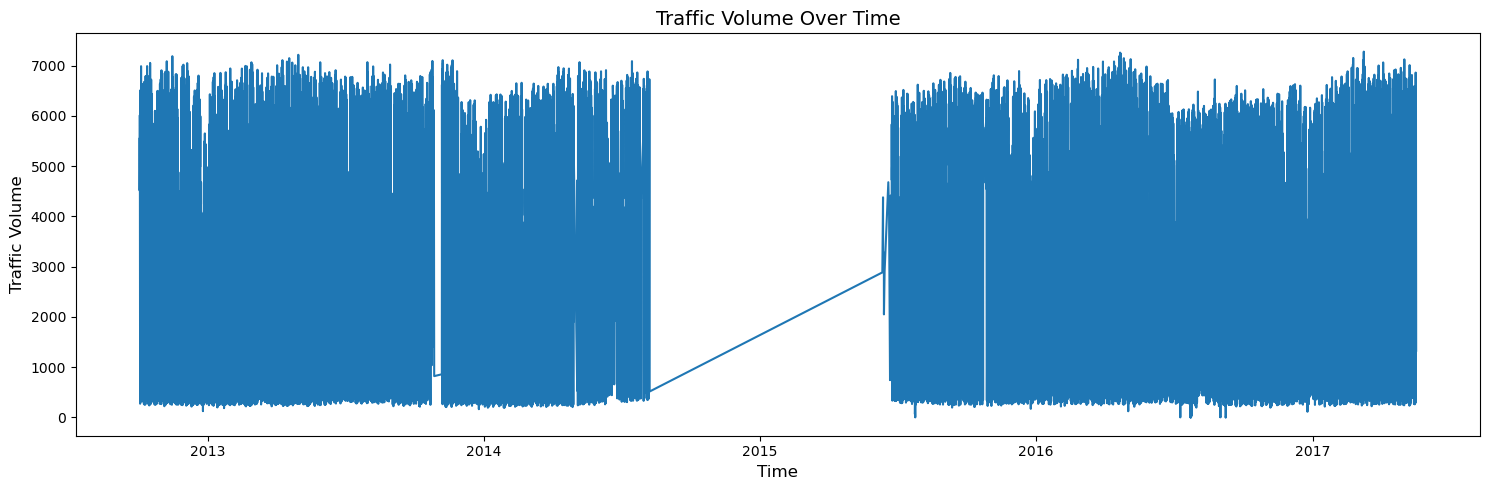

In [10]:
# Ensure index is in datetime format
df.index = pd.to_datetime(df.index)

# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 5))  # Set figure size

# Plot traffic volume using line plot
ax.plot(df.index, df['traffic_volume'])  # Explicitly set datetime index for x-axis

# Formatting
ax.set_xlabel('Time', fontsize=12)  # Set x-axis label
ax.set_ylabel('Traffic Volume', fontsize=12)  # Set y-axis label
ax.set_title('Traffic Volume Over Time', fontsize=14)  # Set title

# Set x-limits using not datetime objects
#ax.set_xlim(0, 33707)

# Show the plot
plt.tight_layout()
plt.show();

In [11]:
# Selecionar apenas as linhas com ano de 2015
df_2014 = df[df.index.year == 2014]

# Visualizar o resultado
df_2014.tail(10)

,temperature,rain_p_h,snow_p_h,humidity,traffic_volume
date_time,,,,,
2014-08-07 16:00:00,300.99,0.0,0.0,79,6731
2014-08-07 17:00:00,300.48,0.0,0.0,80,6278
2014-08-07 18:00:00,299.98,0.0,0.0,76,5121
2014-08-07 19:00:00,299.15,0.0,0.0,79,3826
2014-08-07 20:00:00,297.65,0.0,0.0,77,3441
2014-08-07 21:00:00,295.46,0.0,0.0,75,3274
2014-08-07 22:00:00,294.69,0.0,0.0,72,2479
2014-08-07 23:00:00,294.48,0.0,0.0,70,1491
2014-08-08 00:00:00,293.45,0.0,0.0,69,848


In [12]:
# Selecionar apenas as linhas com ano de 2015
df_2015 = df[df.index.year == 2015]

# Visualizar o resultado
df_2015.head(10)

,temperature,rain_p_h,snow_p_h,humidity,traffic_volume
date_time,,,,,
2015-06-11 20:00:00,287.586,0.0,0.0,65,2886
2015-06-12 18:00:00,297.543,0.0,0.0,65,4380
2015-06-12 20:00:00,292.061,0.0,0.0,63,3095
2015-06-12 21:00:00,292.061,0.0,0.0,63,3299
2015-06-13 21:00:00,294.840,0.0,0.0,68,3040
2015-06-13 23:00:00,293.137,0.0,0.0,66,2051
2015-06-14 20:00:00,296.064,0.0,0.0,70,2909
2015-06-19 18:00:00,299.007,0.0,0.0,70,4681
2015-06-20 18:00:00,295.369,0.0,0.0,74,4045


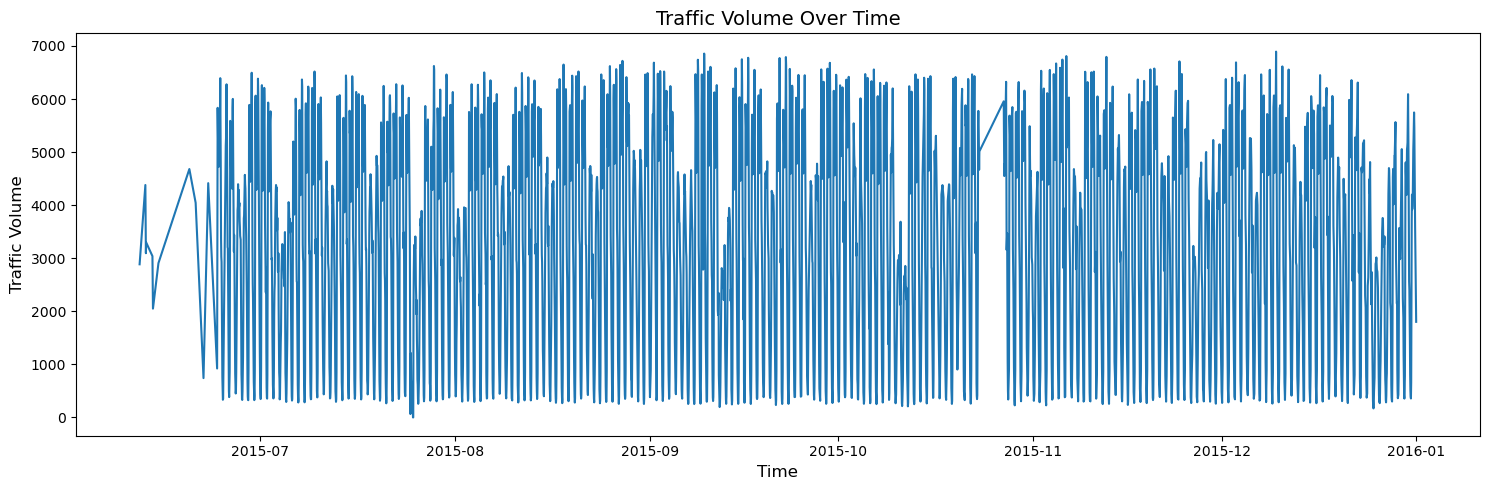

In [13]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 5))  # Set figure size

# Plot traffic volume using line plot
ax.plot(df_2015.index, df_2015['traffic_volume'])  # Explicitly set datetime index for x-axis

# Formatting
ax.set_xlabel('Time', fontsize=12)  # Set x-axis label
ax.set_ylabel('Traffic Volume', fontsize=12)  # Set y-axis label
ax.set_title('Traffic Volume Over Time', fontsize=14)  # Set title

# Set x-limits using not datetime objects
#ax.set_xlim(0, 33707)

# Show the plot
plt.tight_layout()
plt.show();

In [14]:
# Define the start and end of the desired interval
start_date = pd.to_datetime("2015-07-01 06:00:00")
end_date = pd.to_datetime("2015-10-01 06:00:00")

# Filter the DataFrame based on the datetime index
new_df = df[(df.index >= start_date) & (df.index <= end_date)]

# Remove rows with duplicate index values (keeping the first occurrence)
new_df = new_df[~new_df.index.duplicated(keep='first')]

# Show the result
new_df.head(30)

,temperature,rain_p_h,snow_p_h,humidity,traffic_volume
date_time,,,,,
2015-07-01 06:00:00,287.38,0.0,0.0,41,5741
2015-07-01 07:00:00,287.58,0.0,0.0,50,6261
2015-07-01 09:00:00,288.58,0.0,0.0,56,4409
2015-07-01 10:00:00,289.24,0.0,0.0,68,4273
2015-07-01 11:00:00,289.44,0.0,0.0,77,4469
2015-07-01 12:00:00,290.53,0.0,0.0,88,4625
2015-07-01 13:00:00,292.17,0.0,0.0,82,4462
2015-07-01 14:00:00,293.61,0.0,0.0,93,4996
2015-07-01 15:00:00,294.85,0.0,0.0,93,5623


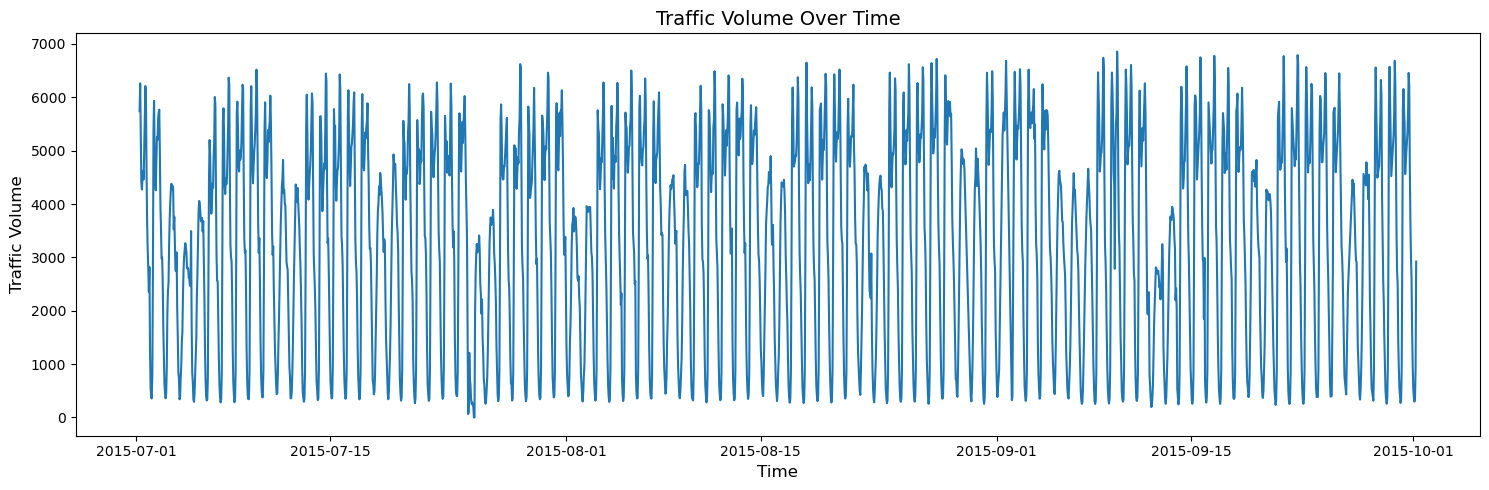

In [15]:
# Ensure index is in datetime format
new_df.index = pd.to_datetime(new_df.index)

# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 5))  # Set figure size

# Plot traffic volume using line plot
ax.plot(new_df.index, new_df['traffic_volume'])  # Explicitly set datetime index for x-axis

# Formatting
ax.set_xlabel('Time', fontsize=12)  # Set x-axis label
ax.set_ylabel('Traffic Volume', fontsize=12)  # Set y-axis label
ax.set_title('Traffic Volume Over Time', fontsize=14)  # Set title

# Set x-limits using not datetime objects
#ax.set_xlim(0, 33707)

# Show the plot
plt.tight_layout()
plt.show();

In [16]:
# Move 'traffic_volume' to the first column
new_df = new_df[['traffic_volume'] + [col for col in new_df.columns if col != 'traffic_volume']]

In [17]:
train = new_df.iloc[:int(0.90*len(new_df))]
test = new_df.iloc[int(0.90*len(new_df)):]

# Show results
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print()
print(train.tail())
print()
print(test.head())

Train shape: (1907, 5)
Test shape: (212, 5)

                     traffic_volume  temperature  rain_p_h  snow_p_h  humidity
date_time                                                                     
2015-09-20 08:00:00            2147       283.84       0.0       0.0        69
2015-09-20 09:00:00            3364       286.63       0.0       0.0        68
2015-09-20 10:00:00            4270       288.74       0.0       0.0        67
2015-09-20 11:00:00            4219       291.42       0.0       0.0        66
2015-09-20 12:00:00            4239       292.74       0.0       0.0        64

                     traffic_volume  temperature  rain_p_h  snow_p_h  humidity
date_time                                                                     
2015-09-20 13:00:00            4124       293.77      0.00       0.0        63
2015-09-20 14:00:00            4070       294.58      0.00       0.0        62
2015-09-20 15:00:00            4185       294.54      0.00       0.0        64
2015-0

In [18]:
#Separate dates for future plotting
train_dates = train.index
valid_dates = test.index

train_dates

DatetimeIndex(['2015-07-01 06:00:00', '2015-07-01 07:00:00',
               '2015-07-01 09:00:00', '2015-07-01 10:00:00',
               '2015-07-01 11:00:00', '2015-07-01 12:00:00',
               '2015-07-01 13:00:00', '2015-07-01 14:00:00',
               '2015-07-01 15:00:00', '2015-07-01 16:00:00',
               ...
               '2015-09-20 03:00:00', '2015-09-20 04:00:00',
               '2015-09-20 05:00:00', '2015-09-20 06:00:00',
               '2015-09-20 07:00:00', '2015-09-20 08:00:00',
               '2015-09-20 09:00:00', '2015-09-20 10:00:00',
               '2015-09-20 11:00:00', '2015-09-20 12:00:00'],
              dtype='datetime64[ns]', name='date_time', length=1907, freq=None)

In [19]:
len(train_dates)

1907

In [20]:
#Variables for training
cols = list(train)[0:6]

#Date are not used in training. 
print(cols)

['traffic_volume', 'temperature', 'rain_p_h', 'snow_p_h', 'humidity']


In [21]:
#New dataframe with only training data - 5 columns
df_for_training = train[cols].astype(float)

In [22]:
#LSTM uses sigmoid and tanh that are sensitive to magnitude so values need to be normalized
# normalize the dataset

scaler = StandardScaler()
scaler = scaler.fit(df_for_training)
df_for_training_scaled = scaler.transform(df_for_training)

In [23]:
#As required for LSTM networks, we require to reshape an input data into n_samples x timesteps x n_features. 
#In this example, the n_features is 5. We will make timesteps = 48 (past days data used for training). 

#Empty lists to be populated using formatted training data
trainX = []
trainY = []

In [24]:
n_future = 1   # Number of days we want to look into the future based on the past days.
window_size = 48    # window_size; Number of past hours we want to use to predict the future.

In [25]:
#Reformat input data into a shape: (n_samples x timesteps x n_features)
#In my example, my df_for_training_scaled has a shape (1907, 5)
#1907 refers to the number of data points and 5 refers to the columns (multi-variables).

for i in range(window_size, len(df_for_training_scaled) - n_future +1):
    
    trainX.append(df_for_training_scaled[i - window_size:i, 0:df_for_training.shape[1]])
    trainY.append(df_for_training_scaled[i + n_future - 1:i + n_future, 0])

In [26]:
trainX, trainY = np.array(trainX), np.array(trainY)

print('trainX shape == {}.'.format(trainX.shape))
print('trainY shape == {}.'.format(trainY.shape))

#In my case, trainX has a shape (1859, 48, 5). 
#1907 because we are looking back 48 hours (1907 - 48 = 1859). 
#Remember that we cannot look back 48 hours until we get to the 49th hour. 
#Also, trainY has a shape (1859, 1). Our model only predicts a single value, but 
#it needs multiple variables (5 in my example) to make this prediction. 
#This is why we can only predict a single hour after our training, the hour after where our data ends.
#To predict more hours in future, we need all the 5 variables which we do not have. 
#We need to predict all variables if we want to do that. 

trainX shape == (1859, 48, 5).
trainY shape == (1859, 1).


In [27]:
trainX.shape[1]

48

In [28]:
trainX.shape[2]

5

In [29]:
trainY.shape[1]

1

In [30]:
# Build the model
model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(trainX.shape[1], trainX.shape[2])),                
        tf.keras.layers.LSTM(64, activation='relu', return_sequences=True),     
        tf.keras.layers.LSTM(32, activation='relu', return_sequences=False),                           
        tf.keras.layers.Dropout(0.2),        
        tf.keras.layers.Dense(trainY.shape[1])                   
])

# Print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 48, 64)              │          17,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Compile the model
model.compile(
    loss=tf.keras.losses.Huber(),            # Robust loss for outliers
    optimizer=tf.keras.optimizers.Adam(),    # Adaptive optimizer
    metrics=["mse"]                          # Mean Squared Error as evaluation metric
)

# Train the model
history = model.fit(trainX, trainY, epochs=100, batch_size=16, validation_split=0.1, verbose=1)

Epoch 1/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.3856 - mse: 0.8293 - val_loss: 0.1754 - val_mse: 0.3679
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1504 - mse: 0.3176 - val_loss: 0.1062 - val_mse: 0.2204
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0907 - mse: 0.1851 - val_loss: 0.0880 - val_mse: 0.1785
Epoch 4/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0813 - mse: 0.1681 - val_loss: 0.0610 - val_mse: 0.1220
Epoch 5/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0725 - mse: 0.1496 - val_loss: 0.0472 - val_mse: 0.0944
Epoch 6/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0526 - mse: 0.1072 - val_loss: 0.0463 - val_mse: 0.0928
Epoch 7/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0508 - mse: 0.1039 - val_loss: 0.0403 - val_mse: 0.0806
Epoch 8/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0511 - mse: 0.1091 - val_loss: 0.0357 - val_mse: 0.0714
Epoch 9/100
105/105 ━━━━━━━━━━━━━━━━━━━━

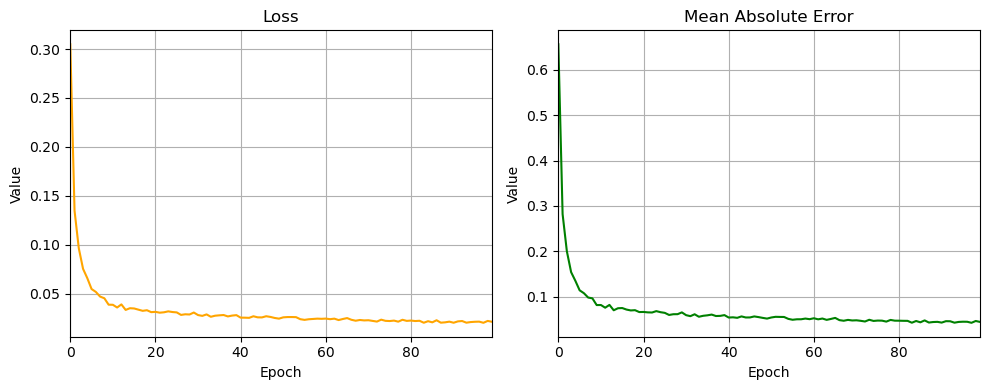

In [32]:
# Create a 1x2 grid for subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))  

# Plot AutoCorrelation Function
axes[0].plot(history.history["loss"], color='orange')
axes[0].set_title("Loss", fontsize=12)
axes[0].set_ylabel("Value")
axes[0].set_xlabel("Epoch")
axes[0].set_xlim(0,99)
axes[0].grid(True)

# Plot Partial Autocorrelation Function
axes[1].plot(history.history["mse"], color='green')
axes[1].set_title("Mean Absolute Error", fontsize=12)
axes[1].set_ylabel("Value")
axes[1].set_xlabel("Epoch")
axes[1].set_xlim(0,99)
axes[1].grid(True)

plt.tight_layout()
plt.show();

### Predicting

```Python
#Libraries that will help us extract only business days in the US.
#Otherwise our dates would be wrong when we look back (or forward).  

from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

us_bd = CustomBusinessDay(calendar=USFederalHolidayCalendar())
```

In [34]:
#Remember that we can only predict one day in future as our model needs 5 variables
#as inputs for prediction. We only have all 5 variables until the last day in our dataset.

n_past = 48                 # window_size
n_hours_for_prediction=212  # Time in the future

predict_period_dates = pd.date_range(list(train_dates)[-n_past], periods=n_hours_for_prediction).tolist() # ', freq=us_bd' (for business days)

#Make prediction
prediction = model.predict(trainX[-n_hours_for_prediction:]) #shape = (n, 1) where n is the n_days_for_prediction

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [35]:
#Perform inverse transformation to rescale back to original range
#Since we used 5 variables for transform, the inverse expects same dimensions
#Therefore, let us copy our values 5 times and discard them after inverse transform

prediction_copies = np.repeat(prediction, df_for_training.shape[1], axis=-1)
y_pred_future = scaler.inverse_transform(prediction_copies)[:,0]

In [36]:
# Keep full datetime with hours
forecast_dates = []
for time_i in predict_period_dates:
    forecast_dates.append(time_i)      # For days, use: forecast_dates.append(time_i.date())

df_forecast = pd.DataFrame({
    'Date': valid_dates, 
    'traffic_volume': y_pred_future
})

df_forecast['Date'] = pd.to_datetime(df_forecast['Date'])
df_forecast.set_index('Date', inplace=True)
df_forecast.head()

,traffic_volume
Date,
2015-09-20 13:00:00,4888.227051
2015-09-20 14:00:00,5182.273438
2015-09-20 15:00:00,5196.847656
2015-09-20 16:00:00,5765.667969
2015-09-20 17:00:00,6134.902344


In [37]:
df_forecast.tail(3)

,traffic_volume
Date,
2015-10-01 03:00:00,4245.350098
2015-10-01 04:00:00,4709.349121
2015-10-01 05:00:00,4500.601562


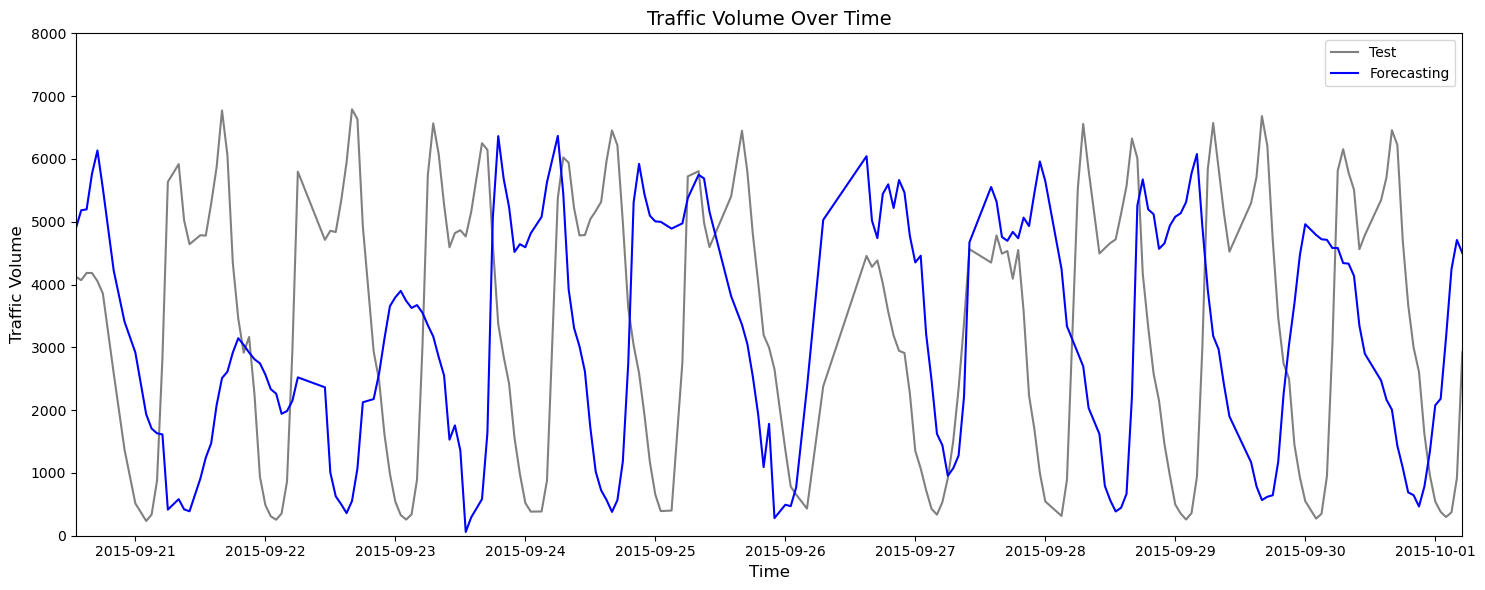

In [38]:
# Plot actual and forecasted series
plt.figure(figsize=(15, 6)) 

plt.plot(test.index, test['traffic_volume'], label='Test', color='gray')
plt.plot(df_forecast.index, df_forecast['traffic_volume'], label='Forecasting', color='blue')

plt.xlabel('Time', fontsize=12)
plt.ylabel('Traffic Volume', fontsize=12)
plt.title('Traffic Volume Over Time', fontsize=14)
plt.xlim(pd.to_datetime('2015-09-20 13:00:00'), pd.to_datetime('2015-10-01 05:00:00'))
plt.ylim(0, 8000)
#plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show();

In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error


# Metrics
mae_s = mean_absolute_error(test['traffic_volume'], df_forecast['traffic_volume'])
rmse_s = np.sqrt(mean_squared_error(test['traffic_volume'], df_forecast['traffic_volume']))
mape_s = mean_absolute_percentage_error(test['traffic_volume'], df_forecast['traffic_volume']) * 100

# Combine into dictionaries
metrics_S = {
    'MAE': mae_s,
    'RMSE': rmse_s,
    'MAPE': mape_s,
}

# Create DataFrame for Error Analysis
comparison_df = pd.DataFrame([metrics_S]).T.round(2) 
comparison_df

,0
MAE,2680.12
RMSE,3097.29
MAPE,215.19


End.